# Credit Risk Modelling — Part 1: Data Reading & Validation
---
**Objective:** Load the four raw datasets, understand their structure, verify data integrity, and surface any quality issues before modelling.

**Checks performed:**
1. Load all four files & inspect raw shapes
2. Identify feature types (numeric vs categorical)
3. Feature family breakdown
4. Merge integrity (X ↔ y alignment)
5. Leakage & duplicate checks
6. Label distribution & class imbalance
7. Missing value deep-dive
8. Bureau score (`score_1`) analysis
9. Outlier scan (IQR method)
10. Summary validation report
11. Visualisations

## Imports & Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

# ── File paths ────────────────────────────────────────────────



TRAIN_X = "/Users/parveenkumarsharma/Documents/Ecom_project/Credit_risk_model/MP Credit Modelling Takehome Task (train + test) - X_train.csv"
TEST_X = "/Users/parveenkumarsharma/Documents/Ecom_project/Credit_risk_model/MP Credit Modelling Takehome Task (train + test) - X_test.csv"

TRAIN_Y = "/Users/parveenkumarsharma/Documents/Ecom_project/Credit_risk_model/MP Credit Modelling Takehome Task (train + test) - Y_train.csv"
TEST_Y = "/Users/parveenkumarsharma/Documents/Ecom_project/Credit_risk_model/MP Credit Modelling Takehome Task (train + test) - Y_test.csv"
BLUE   = "#4472C4"
ORANGE = "#ED7D31"
GREEN  = "#70AD47"
GRAY   = "#9E9E9E"

issues   = []   # blocking data quality problems
warnings_list = []   # non-blocking observations
print("✓ Setup complete")

✓ Setup complete


---
## Step 1 — Load Raw Files

Load all four CSVs and print their shapes and column previews.

In [5]:
X_train_raw = pd.read_csv(TRAIN_X)
y_train_raw = pd.read_csv(TRAIN_Y)
X_test_raw  = pd.read_csv(TEST_X)
y_test_raw  = pd.read_csv(TEST_Y)

print(f"{'File':<12} {'Shape':<20} {'First 4 columns'}")
print("-" * 70)
for name, df in [("X_train", X_train_raw), ("y_train", y_train_raw),
                  ("X_test",  X_test_raw),  ("y_test",  y_test_raw)]:
    print(f"{name:<12} {str(df.shape):<20} {list(df.columns[:4])}")

print("\n✓ All 4 files loaded successfully")

File         Shape                First 4 columns
----------------------------------------------------------------------
X_train      (28399, 101)         ['account_id', 'score_1', 'balance_1', 'balance_2']
y_train      (28397, 2)           ['account_id', 'label']
X_test       (4000, 101)          ['account_id', 'score_1', 'balance_1', 'balance_2']
y_test       (4000, 2)            ['account_id', 'label']

✓ All 4 files loaded successfully


---
## Step 2 — Feature Type Identification

Separate features into **numeric** (float64) and **categorical** (string/object) columns.

In [6]:
feature_cols = [c for c in X_train_raw.columns if c != "account_id"]
cat_cols     = [c for c in feature_cols if str(X_train_raw[c].dtype) in ("object", "str")]
num_cols     = [c for c in feature_cols if c not in cat_cols]

print(f"Total features    : {len(feature_cols)}")
print(f"Numeric features  : {len(num_cols)}")
print(f"Categorical feats : {len(cat_cols)}")

print(f"\nCategorical columns & their unique values:")
for col in cat_cols:
    uniq       = sorted(X_train_raw[col].dropna().unique().tolist())
    null_count = X_train_raw[col].isnull().sum()
    null_pct   = null_count / len(X_train_raw) * 100
    print(f"  {col}")
    print(f"    Values : {uniq}")
    print(f"    Nulls  : {null_count:,} ({null_pct:.1f}%)")

print(f"\nNumeric dtype breakdown:")
for dtype, cnt in X_train_raw[num_cols].dtypes.value_counts().items():
    print(f"  {str(dtype):<12}: {cnt} features")

Total features    : 100
Numeric features  : 98
Categorical feats : 2

Categorical columns & their unique values:
  financial_situation_4
    Values : ['N1', 'N2', 'N3', 'N4', 'ND', 'P1', 'P2', 'P3', 'P4', 'S1', 'S2', 'S3', 'S4']
    Nulls  : 2 (0.0%)
  financial_situation_5
    Values : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
    Nulls  : 2 (0.0%)

Numeric dtype breakdown:
  float64     : 98 features


---
## Step 3 — Feature Family Breakdown

The feature names follow a pattern like `balance_1`, `utilization_3`, etc.  
We extract the **family prefix** to understand which credit concepts are represented.

In [7]:
families = {}
for c in feature_cols:
    m   = re.match(r"^([a-z_]+?)_\d+$", c)
    fam = m.group(1) if m else "other"
    families.setdefault(fam, []).append(c)

print(f"{'Family':<28} {'# Features':>10}  {'Example columns'}")
print(f"{'-'*28} {'-'*10}  {'-'*28}")
for fam, cols in sorted(families.items()):
    examples = ", ".join(cols[:3]) + ("..." if len(cols) > 3 else "")
    print(f"{fam:<28} {len(cols):>10}  {examples}")

print("\nKey domain intuitions:")
intuitions = {
    "repayment_history": "past payment behaviour — strongest default predictor",
    "balance":           "outstanding amounts across product types",
    "utilization":       "credit usage ratio — high utilization → higher risk",
    "recency":           "months since last event — NaN = event never occurred",
    "score":             "pre-trained bureau score — our key benchmark",
    "spend_behaviour":   "spending patterns across channels",
    "financial_situation":"categorical + numeric financial status indicators",
    "credit_limit":      "approved credit limits by product",
    "demand_for_credit": "number of recent credit applications",
}
for fam, note in intuitions.items():
    n = len(families.get(fam, []))
    print(f"  • {fam} ({n} feature{'s' if n!=1 else ''}) — {note}")

Family                       # Features  Example columns
---------------------------- ----------  ----------------------------
balance                              24  balance_1, balance_2, balance_3...
credit_limit                          3  credit_limit_1, credit_limit_2, credit_limit_3
demand_for_credit                     1  demand_for_credit_1
financial_situation                   5  financial_situation_1, financial_situation_2, financial_situation_3...
recency                              12  recency_1, recency_2, recency_3...
repayment_history                    31  repayment_history_1, repayment_history_2, repayment_history_3...
score                                 1  score_1
spend_behaviour                       5  spend_behaviour_1, spend_behaviour_2, spend_behaviour_3...
utilization                          18  utilization_1, utilization_2, utilization_3...

Key domain intuitions:
  • repayment_history (31 features) — past payment behaviour — strongest default predictor
  

---
## Step 4 — Merge Integrity (X ↔ y alignment)

Verify that `account_id` keys align correctly between feature files and label files,  
and check whether any rows are lost during the merge.

In [8]:
x_train_ids = set(X_train_raw["account_id"])
y_train_ids = set(y_train_raw["account_id"])
x_only      = x_train_ids - y_train_ids
y_only      = y_train_ids - x_train_ids

print(f"X_train rows: {len(X_train_raw):,}  |  y_train rows: {len(y_train_raw):,}")
print(f"IDs in X_train but NOT in y_train : {len(x_only)}")
print(f"IDs in y_train but NOT in X_train : {len(y_only)}")

if len(x_only) > 0:
    warnings_list.append(f"{len(x_only)} account_id(s) in X_train have no label → dropped on merge")
    print(f"\n⚠  WARNING: {len(x_only)} X_train row(s) have no matching label — dropped on merge")
    print(f"   Orphaned IDs: {list(x_only)}")

# Perform merge
train = X_train_raw.merge(y_train_raw, on="account_id")
test  = X_test_raw.merge(y_test_raw,   on="account_id")

print(f"\nAfter merge:")
print(f"  train shape : {train.shape}")
print(f"  test  shape : {test.shape}")

x_test_ids = set(X_test_raw["account_id"])
y_test_ids = set(y_test_raw["account_id"])
if x_test_ids == y_test_ids:
    print("\n✓ X_test and y_test account_ids match perfectly")
else:
    issues.append("X_test / y_test account_id mismatch")
    print("\n✗ ISSUE: X_test / y_test account_id mismatch")

X_train rows: 28,399  |  y_train rows: 28,397
IDs in X_train but NOT in y_train : 2
IDs in y_train but NOT in X_train : 0

⚠  WARNING: 2 X_train row(s) have no matching label — dropped on merge
   Orphaned IDs: [nan, 28397.0]

After merge:
  train shape : (28397, 102)
  test  shape : (4000, 102)

✓ X_test and y_test account_ids match perfectly


---
## Step 5 — Leakage & Duplicate Checks

Two critical data integrity checks:
- **Leakage**: same customer appearing in both train and test sets
- **Duplicates**: same row appearing more than once

In [9]:
# ── Train/Test overlap (leakage check) ──────────────────────
overlap = x_train_ids & x_test_ids
print(f"Train/Test account_id overlap: {len(overlap)}")
if len(overlap) == 0:
    print("✓ No leakage — zero account_ids shared between train and test")
else:
    issues.append(f"DATA LEAKAGE: {len(overlap)} account_ids in both train and test")
    print(f"✗ CRITICAL: DATA LEAKAGE — {len(overlap)} shared account_ids")

# ── Duplicate account_ids ─────────────────────────────────────
print("\nDuplicate account_ids:")
for name, df in [("X_train", X_train_raw), ("y_train", y_train_raw),
                  ("X_test",  X_test_raw),  ("y_test",  y_test_raw)]:
    dups = df.duplicated("account_id").sum()
    flag = "✓" if dups == 0 else "✗"
    print(f"  {flag} {name:<10}: {dups} duplicate(s)")
    if dups > 0:
        issues.append(f"{name} has {dups} duplicate account_ids")

# ── Fully duplicate rows ──────────────────────────────────────
print("\nFully duplicate rows (all columns identical):")
for name, df in [("X_train", X_train_raw), ("X_test", X_test_raw)]:
    dups = df.drop(columns=["account_id"]).duplicated().sum()
    flag = "✓" if dups == 0 else "⚠"
    print(f"  {flag} {name:<10}: {dups} fully duplicate row(s)")
    if dups > 0:
        warnings_list.append(f"{name} has {dups} fully duplicate rows (all feature values identical)")

Train/Test account_id overlap: 0
✓ No leakage — zero account_ids shared between train and test

Duplicate account_ids:
  ✓ X_train   : 0 duplicate(s)
  ✓ y_train   : 0 duplicate(s)
  ✓ X_test    : 0 duplicate(s)
  ✓ y_test    : 0 duplicate(s)

Fully duplicate rows (all columns identical):
  ⚠ X_train   : 1 fully duplicate row(s)
  ✓ X_test    : 0 fully duplicate row(s)


---
## Step 6 — Label Distribution & Class Imbalance

The label `1` means the account defaulted within 12 months.  
Understanding the imbalance is crucial for choosing the right evaluation metrics and training strategy.

In [10]:
for split_name, df in [("TRAIN", train), ("TEST", test)]:
    vc       = df["label"].value_counts().sort_index()
    n_total  = len(df)
    n_def    = vc.get(1, 0)
    n_nodef  = vc.get(0, 0)
    ratio    = n_nodef / n_def if n_def > 0 else float("inf")

    print(f"{split_name} SET  (n = {n_total:,})")
    print(f"  No Default (0) : {n_nodef:>6,}  ({n_nodef/n_total*100:.2f}%)")
    print(f"  Default    (1) : {n_def:>6,}  ({n_def/n_total*100:.2f}%)")
    print(f"  Imbalance ratio: {ratio:.1f} : 1  (non-default : default)\n")

train_dr = train["label"].mean()
test_dr  = test["label"].mean()
dr_diff  = abs(train_dr - test_dr)
print(f"Default rate — Train: {train_dr*100:.2f}%  |  Test: {test_dr*100:.2f}%  |  Diff: {dr_diff*100:.2f}%")
print(f"{'✓ Consistent (stratified split)' if dr_diff < 0.01 else '⚠ Check if split was stratified'}")
print(f"\nImplication: A naïve all-zero model gets {(1-train_dr)*100:.1f}% accuracy — accuracy is useless here.")
print(f"Primary metrics → ROC-AUC  and  Average Precision (PR-AUC)")
print(f"Training strategy → class_weight='balanced' or sample weights (ratio ~{train['label'].value_counts()[0]/train['label'].value_counts()[1]:.0f}:1)")

TRAIN SET  (n = 28,397)
  No Default (0) : 26,754  (94.21%)
  Default    (1) :  1,643  (5.79%)
  Imbalance ratio: 16.3 : 1  (non-default : default)

TEST SET  (n = 4,000)
  No Default (0) :  3,766  (94.15%)
  Default    (1) :    234  (5.85%)
  Imbalance ratio: 16.1 : 1  (non-default : default)

Default rate — Train: 5.79%  |  Test: 5.85%  |  Diff: 0.06%
✓ Consistent (stratified split)

Implication: A naïve all-zero model gets 94.2% accuracy — accuracy is useless here.
Primary metrics → ROC-AUC  and  Average Precision (PR-AUC)
Training strategy → class_weight='balanced' or sample weights (ratio ~16:1)


---
## Step 7 — Missing Value Deep-Dive

Almost every feature has some missing values. In credit bureau data, **NaN is informative** —  
it typically means an event never occurred (e.g. no missed payment = `recency_1` is NaN).  
We will add **missingness indicator flags** rather than simply imputing.

In [11]:
miss_pct = X_train_raw[num_cols].isnull().mean() * 100
miss_df  = miss_pct.reset_index()
miss_df.columns = ["feature", "missing_pct"]
miss_df["family"] = miss_df["feature"].apply(
    lambda c: re.match(r"^([a-z_]+?)_\d+$", c).group(1)
              if re.match(r"^([a-z_]+?)_\d+$", c) else "other"
)

buckets = {
    "No missing  (0%)"   : miss_df[miss_df["missing_pct"] == 0],
    "Low  ( 0– 5%)"      : miss_df[(miss_df["missing_pct"] > 0)  & (miss_df["missing_pct"] <= 5)],
    "Med  ( 5–20%)"      : miss_df[(miss_df["missing_pct"] > 5)  & (miss_df["missing_pct"] <= 20)],
    "High (20–50%)"      : miss_df[(miss_df["missing_pct"] > 20) & (miss_df["missing_pct"] <= 50)],
    "Very high (>50%)"   : miss_df[miss_df["missing_pct"] > 50],
}

print("Missing value buckets:")
for label, subset in buckets.items():
    print(f"  {label:<22}: {len(subset):>3} features")

print("\nMissing % by feature family (mean / max):")
fam_miss = miss_df.groupby("family")["missing_pct"].agg(["mean","max","count"])
fam_miss.columns = ["avg_missing%", "max_missing%", "n_features"]
fam_miss = fam_miss.sort_values("avg_missing%", ascending=False)
print(fam_miss.round(1).to_string())

print("\nDomain interpretation:")
print("  • recency        → NaN = event never occurred (no missed payment, etc.)")
print("  • balance        → NaN = no account of this product type")
print("  • utilization    → NaN = no credit line of this type")
print("  • repayment_hist → NaN = no repayment history on this product")
print("  Strategy: add binary missingness flags, then impute with median")

Missing value buckets:
  No missing  (0%)      :   0 features
  Low  ( 0– 5%)         :  19 features
  Med  ( 5–20%)         :  21 features
  High (20–50%)         :  28 features
  Very high (>50%)      :  30 features

Missing % by feature family (mean / max):
                     avg_missing%  max_missing%  n_features
family                                                     
spend_behaviour              62.2          85.2           5
utilization                  39.1          93.9          18
balance                      37.9          94.1          24
financial_situation          36.0          88.0           3
demand_for_credit            33.6          33.6           1
credit_limit                 32.6          53.2           3
recency                      28.2          94.6          12
repayment_history            25.6          94.6          31
score                         0.0           0.0           1

Domain interpretation:
  • recency        → NaN = event never occurred (no mis

In [12]:
# ── Train vs Test missingness consistency ────────────────────
miss_test    = X_test_raw[num_cols].isnull().mean() * 100
miss_compare = pd.DataFrame({"train_missing%": miss_pct, "test_missing%": miss_test})
miss_compare["diff"] = (miss_compare["train_missing%"] - miss_compare["test_missing%"]).abs()
large_diff   = miss_compare[miss_compare["diff"] > 10]

if len(large_diff) > 0:
    warnings_list.append(f"{len(large_diff)} features differ >10pp in missing rate between train and test")
    print(f"⚠  {len(large_diff)} features have >10pp missing rate difference (train vs test):")
    print(large_diff.sort_values("diff", ascending=False).head(10).round(1).to_string())
else:
    print(f"✓ Train/Test missing patterns are consistent (max diff = {miss_compare['diff'].max():.1f}pp)")

✓ Train/Test missing patterns are consistent (max diff = 1.5pp)


---
## Step 8 — Bureau Score (`score_1`) Analysis

`score_1` is a **pre-trained model score** from the credit reference agency.  
It serves as our external benchmark — our model should ideally beat it.

In [13]:
score_train = train["score_1"]
score_test  = test["score_1"]

print("Training set score_1 statistics:")
stats = score_train.describe(percentiles=[.05, .25, .5, .75, .95])
for k, v in stats.items():
    print(f"  {k:<8}: {v:>10.2f}")

print(f"\nNull count — Train: {score_train.isnull().sum()}  |  Test: {score_test.isnull().sum()}")

s_def   = train[train["label"] == 1]["score_1"].dropna()
s_nodef = train[train["label"] == 0]["score_1"].dropna()
print(f"\nscore_1 mean by label:")
print(f"  Default    (1) : {s_def.mean():>8.2f}  (std = {s_def.std():.2f})")
print(f"  No Default (0) : {s_nodef.mean():>8.2f}  (std = {s_nodef.std():.2f})")
direction = "LOWER" if s_def.mean() < s_nodef.mean() else "HIGHER"
print(f"  → {direction} score_1 = higher default risk")

print(f"\nScore range:")
print(f"  Train : [{score_train.min():.1f},  {score_train.max():.1f}]")
print(f"  Test  : [{score_test.min():.1f},  {score_test.max():.1f}]")

Training set score_1 statistics:
  count   :   28397.00
  mean    :     721.66
  std     :     159.84
  min     :     436.73
  5%      :     506.22
  25%     :     593.53
  50%     :     686.70
  75%     :     850.38
  95%     :    1007.47
  max     :    1102.14

Null count — Train: 0  |  Test: 0

score_1 mean by label:
  Default    (1) :   568.83  (std = 74.93)
  No Default (0) :   731.05  (std = 158.90)
  → LOWER score_1 = higher default risk

Score range:
  Train : [436.7,  1102.1]
  Test  : [439.4,  1098.4]


---
## Step 9 — Outlier Scan (IQR Method)

Scan for extreme values using the 3×IQR rule.  
Note: The task description states **noise has been intentionally added** to features.  
Tree-based models are naturally robust to outliers — no clipping is planned.

In [14]:
outlier_rows = []
for col in num_cols[:50]:   # scan first 50 numeric cols as representative sample
    q1  = train[col].quantile(0.25)
    q3  = train[col].quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        continue
    lo    = q1 - 3 * iqr
    hi    = q3 + 3 * iqr
    n_out = ((train[col] < lo) | (train[col] > hi)).sum()
    pct   = n_out / train[col].notna().sum() * 100
    if pct > 1:
        outlier_rows.append({"feature": col, "outlier_%": round(pct, 2), "n_outliers": n_out})

outlier_df = pd.DataFrame(outlier_rows).sort_values("outlier_%", ascending=False)

if len(outlier_df) == 0:
    print("✓ No features with >1% extreme outliers found in first 50 features")
else:
    print(f"Features with >1% extreme outliers (3×IQR rule, first 50 features scanned):")
    print(outlier_df.head(10).to_string(index=False))
    print(f"\nNote: Noise was added intentionally per task description.")
    print(f"Tree-based models handle outliers natively → no clipping planned.")

Features with >1% extreme outliers (3×IQR rule, first 50 features scanned):
             feature  outlier_%  n_outliers
repayment_history_11      20.83        2677
 repayment_history_9      17.79        4003
       utilization_4      15.25        3456
           balance_4      13.19        3667
          balance_12      12.92        3364
   spend_behaviour_1      11.65         527
       utilization_7       8.41        1083
           recency_4       6.42        1739
repayment_history_12       6.35        1803
 repayment_history_8       6.32        1573

Note: Noise was added intentionally per task description.
Tree-based models handle outliers natively → no clipping planned.


---
## Step 10 — Validation Summary Report

Consolidate all findings into a final quality report.

In [15]:
vc_train = train["label"].value_counts().sort_index()

print("┌─────────────────────────────────────────────────────┐")
print("│              DATASET SUMMARY                        │")
print("├─────────────────────────────────────────────────────┤")
print(f"│  Training samples     : {len(train):>7,}                   │")
print(f"│  Test samples         : {len(test):>7,}                   │")
print(f"│  Features (raw)       : {len(feature_cols):>7,}                   │")
print(f"│  Numeric features     : {len(num_cols):>7,}                   │")
print(f"│  Categorical features : {len(cat_cols):>7,}                   │")
print(f"│  Feature families     : {len(families):>7,}                   │")
print(f"│                                                     │")
print(f"│  Train default rate   : {train['label'].mean()*100:>7.2f}%                  │")
print(f"│  Test  default rate   : {test['label'].mean()*100:>7.2f}%                  │")
print(f"│  Imbalance ratio      :  {vc_train[0]/vc_train[1]:>5.1f} : 1               │")
print(f"│                                                     │")
print(f"│  Features 0% missing  : {(miss_pct==0).sum():>7,}                   │")
print(f"│  Features >50% missing: {(miss_pct>50).sum():>7,}                   │")
print(f"│  score_1 NaN (train)  : {score_train.isnull().sum():>7,}                   │")
print("└─────────────────────────────────────────────────────┘")

print(f"\nISSUES  ({len(issues)} found):")
if issues:
    for i, iss in enumerate(issues, 1): print(f"  ✗ [{i}] {iss}")
else:
    print("  ✓ No blocking issues found")

print(f"\nWARNINGS  ({len(warnings_list)} found):")
if warnings_list:
    for i, w in enumerate(warnings_list, 1): print(f"  ⚠ [{i}] {w}")
else:
    print("  ✓ No warnings")

┌─────────────────────────────────────────────────────┐
│              DATASET SUMMARY                        │
├─────────────────────────────────────────────────────┤
│  Training samples     :  28,397                   │
│  Test samples         :   4,000                   │
│  Features (raw)       :     100                   │
│  Numeric features     :      98                   │
│  Categorical features :       2                   │
│  Feature families     :       9                   │
│                                                     │
│  Train default rate   :    5.79%                  │
│  Test  default rate   :    5.85%                  │
│  Imbalance ratio      :   16.3 : 1               │
│                                                     │
│  Features 0% missing  :       0                   │
│  Features >50% missing:      30                   │
│  score_1 NaN (train)  :       0                   │
└─────────────────────────────────────────────────────┘

ISSUES  (0 found

---
## Step 11 — Visualisations

### 11.1 — Overview Dashboard

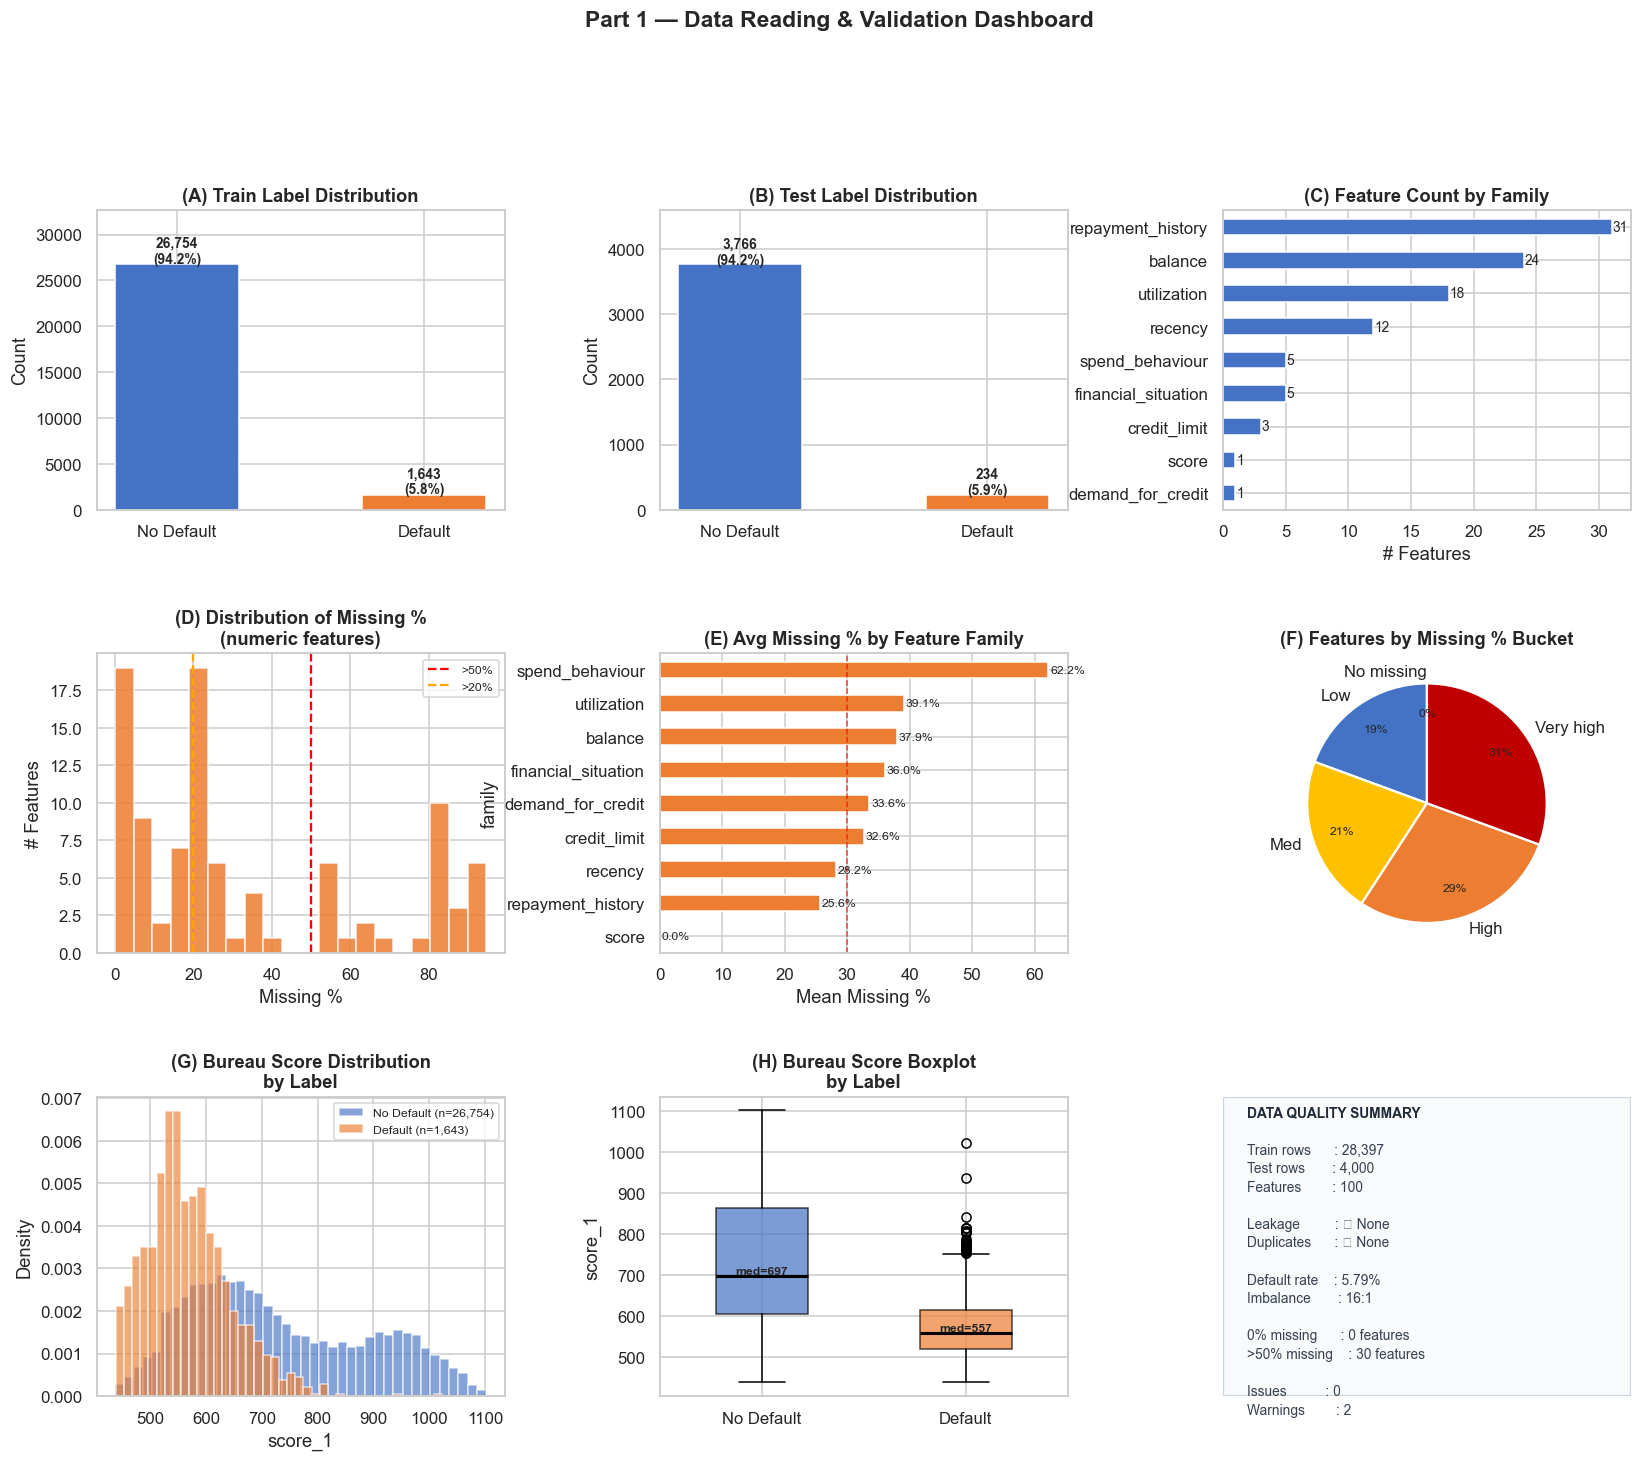

In [16]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle("Part 1 — Data Reading & Validation Dashboard",
             fontsize=15, fontweight="bold", y=1.01)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.38)

# (A) Label distribution — Train
ax = fig.add_subplot(gs[0, 0])
vc = train["label"].value_counts().sort_index()
bars = ax.bar(["No Default", "Default"], vc.values,
              color=[BLUE, ORANGE], edgecolor="white", width=0.5)
ax.set_title("(A) Train Label Distribution", fontweight="bold")
ax.set_ylabel("Count")
for bar, val in zip(bars, vc.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+120,
            f"{val:,}\n({val/len(train)*100:.1f}%)",
            ha="center", fontsize=9, fontweight="bold")
ax.set_ylim(0, max(vc.values) * 1.22)

# (B) Label distribution — Test
ax = fig.add_subplot(gs[0, 1])
vc2 = test["label"].value_counts().sort_index()
bars2 = ax.bar(["No Default", "Default"], vc2.values,
               color=[BLUE, ORANGE], edgecolor="white", width=0.5)
ax.set_title("(B) Test Label Distribution", fontweight="bold")
ax.set_ylabel("Count")
for bar, val in zip(bars2, vc2.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
            f"{val:,}\n({val/len(test)*100:.1f}%)",
            ha="center", fontsize=9, fontweight="bold")
ax.set_ylim(0, max(vc2.values) * 1.22)

# (C) Feature count by family
ax = fig.add_subplot(gs[0, 2])
fam_counts = pd.Series({fam: len(cols) for fam, cols in sorted(families.items())})
fam_counts.sort_values(ascending=True).plot(kind="barh", ax=ax, color=BLUE, edgecolor="white")
ax.set_title("(C) Feature Count by Family", fontweight="bold")
ax.set_xlabel("# Features")
for i, (fam, cnt) in enumerate(fam_counts.sort_values().items()):
    ax.text(cnt+0.1, i, str(cnt), va="center", fontsize=9)

# (D) Missing % histogram
ax = fig.add_subplot(gs[1, 0])
ax.hist(miss_pct.values, bins=20, color=ORANGE, edgecolor="white", alpha=0.85)
ax.axvline(50, color="red",    linestyle="--", linewidth=1.5, label=">50%")
ax.axvline(20, color="orange", linestyle="--", linewidth=1.5, label=">20%")
ax.set_title("(D) Distribution of Missing %\n(numeric features)", fontweight="bold")
ax.set_xlabel("Missing %"); ax.set_ylabel("# Features")
ax.legend(fontsize=8)

# (E) Avg missing % by family
ax = fig.add_subplot(gs[1, 1])
fam_avg_miss = miss_df.groupby("family")["missing_pct"].mean().sort_values(ascending=True)
fam_avg_miss.plot(kind="barh", ax=ax, color=ORANGE, edgecolor="white")
ax.set_title("(E) Avg Missing % by Feature Family", fontweight="bold")
ax.set_xlabel("Mean Missing %")
ax.axvline(30, color="red", linestyle="--", linewidth=1, alpha=0.7)
for i, val in enumerate(fam_avg_miss.values):
    ax.text(val+0.3, i, f"{val:.1f}%", va="center", fontsize=8)

# (F) Missing bucket pie chart
ax = fig.add_subplot(gs[1, 2])
bucket_sizes  = [len(v) for v in buckets.values()]
bucket_labels = [k.split("(")[0].strip() for k in buckets.keys()]
bucket_colors = [GREEN, BLUE, "#FFC000", ORANGE, "#C00000"]
wedges, texts, autotexts = ax.pie(
    bucket_sizes, labels=bucket_labels,
    colors=bucket_colors, autopct="%1.0f%%",
    startangle=90, pctdistance=0.75,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
for at in autotexts: at.set_fontsize(8)
ax.set_title("(F) Features by Missing % Bucket", fontweight="bold")

# (G) score_1 distribution by label
ax = fig.add_subplot(gs[2, 0])
for lbl, color, name in [(0, BLUE, "No Default"), (1, ORANGE, "Default")]:
    vals = train[train["label"]==lbl]["score_1"].dropna()
    ax.hist(vals, bins=40, alpha=0.65, color=color,
            label=f"{name} (n={len(vals):,})", density=True)
ax.set_title("(G) Bureau Score Distribution\nby Label", fontweight="bold")
ax.set_xlabel("score_1"); ax.set_ylabel("Density"); ax.legend(fontsize=8)

# (H) score_1 boxplot
ax = fig.add_subplot(gs[2, 1])
train_plot = train[["score_1","label"]].copy()
train_plot["Group"] = train_plot["label"].map({0:"No Default", 1:"Default"})
groups = [train_plot[train_plot["Group"]==g]["score_1"].dropna() for g in ["No Default","Default"]]
bp = ax.boxplot(groups, labels=["No Default","Default"],
                patch_artist=True, widths=0.45,
                medianprops={"color":"black","linewidth":2})
for patch, color in zip(bp["boxes"], [BLUE, ORANGE]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_title("(H) Bureau Score Boxplot\nby Label", fontweight="bold")
ax.set_ylabel("score_1")
for i, vals in enumerate(groups):
    ax.text(i+1, vals.median()+5, f"med={vals.median():.0f}",
            ha="center", fontsize=8, fontweight="bold")

# (I) Summary text box
ax = fig.add_subplot(gs[2, 2])
ax.axis("off")
ax.add_patch(plt.Rectangle((0,0), 1, 1, transform=ax.transAxes,
                             facecolor="#F8FAFC", edgecolor="#CBD5E1", linewidth=1.5))
lines = [
    ("DATA QUALITY SUMMARY", True),  ("", False),
    (f"Train rows      : {len(train):,}", False),
    (f"Test rows       : {len(test):,}", False),
    (f"Features        : {len(feature_cols)}", False),  ("", False),
    (f"Leakage         : {'✓ None' if len(set(X_train_raw.account_id)&set(X_test_raw.account_id))==0 else '✗ FOUND'}", False),
    (f"Duplicates      : ✓ None", False),  ("", False),
    (f"Default rate    : {train['label'].mean()*100:.2f}%", False),
    (f"Imbalance       : {vc[0]/vc[1]:.0f}:1", False),  ("", False),
    (f"0% missing      : {(miss_pct==0).sum()} features", False),
    (f">50% missing    : {(miss_pct>50).sum()} features", False),  ("", False),
    (f"Issues          : {len(issues)}", False),
    (f"Warnings        : {len(warnings_list)}", False),
]
y_pos = 0.97
for text, bold in lines:
    ax.text(0.06, y_pos, text, transform=ax.transAxes,
            fontsize=9, fontweight="bold" if bold else "normal",
            color="#1F2937" if bold else "#374151", va="top")
    y_pos -= 0.062

plt.tight_layout()
plt.show()

### 11.2 — Missing Value Detail by Feature

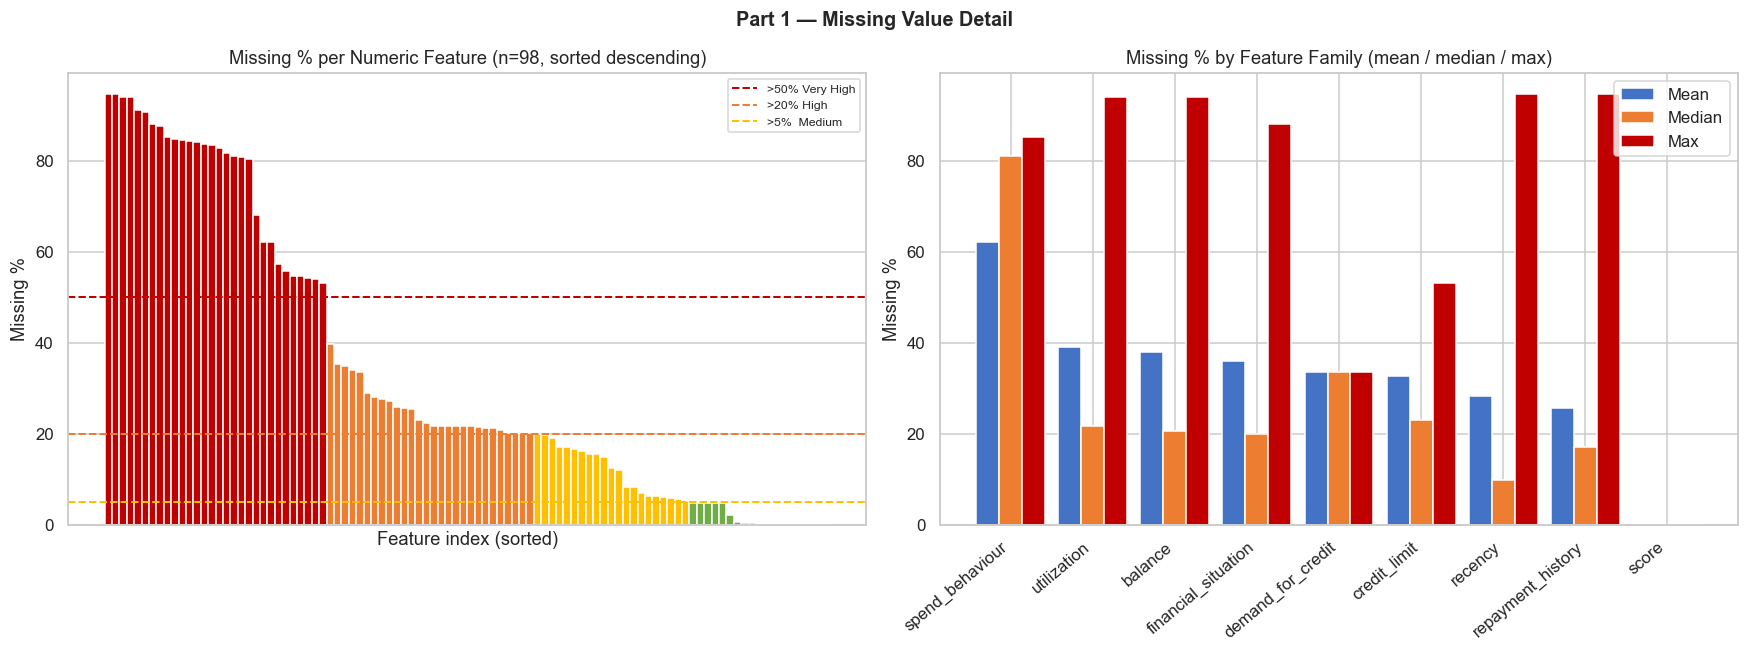

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Part 1 — Missing Value Detail", fontsize=13, fontweight="bold")

# Left: bar chart per feature
ax = axes[0]
miss_sorted = miss_pct.sort_values(ascending=False)
bar_colors  = ["#C00000" if v > 50 else "#ED7D31" if v > 20
               else "#FFC000" if v > 5 else "#70AD47"
               for v in miss_sorted.values]
ax.bar(range(len(miss_sorted)), miss_sorted.values, color=bar_colors, width=1.0)
ax.axhline(50, color="#C00000",  linestyle="--", lw=1.3, label=">50% Very High")
ax.axhline(20, color="#ED7D31",  linestyle="--", lw=1.3, label=">20% High")
ax.axhline(5,  color="#FFC000",  linestyle="--", lw=1.3, label=">5%  Medium")
ax.set_title(f"Missing % per Numeric Feature (n={len(miss_sorted)}, sorted descending)")
ax.set_xlabel("Feature index (sorted)"); ax.set_ylabel("Missing %")
ax.set_xticks([]); ax.legend(fontsize=8)

# Right: grouped bar by family (mean / median / max)
ax = axes[1]
fam_detail = miss_df.groupby("family")["missing_pct"].agg(
    mean="mean", median="median", max="max"
).sort_values("mean", ascending=False)
x = np.arange(len(fam_detail)); w = 0.28
ax.bar(x-w, fam_detail["mean"],   width=w, label="Mean",   color=BLUE,   edgecolor="white")
ax.bar(x,   fam_detail["median"], width=w, label="Median", color=ORANGE, edgecolor="white")
ax.bar(x+w, fam_detail["max"],    width=w, label="Max",    color="#C00000", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(fam_detail.index, rotation=40, ha="right")
ax.set_title("Missing % by Feature Family (mean / median / max)")
ax.set_ylabel("Missing %"); ax.legend()

plt.tight_layout()
plt.show()

### 11.3 — Categorical Feature Analysis

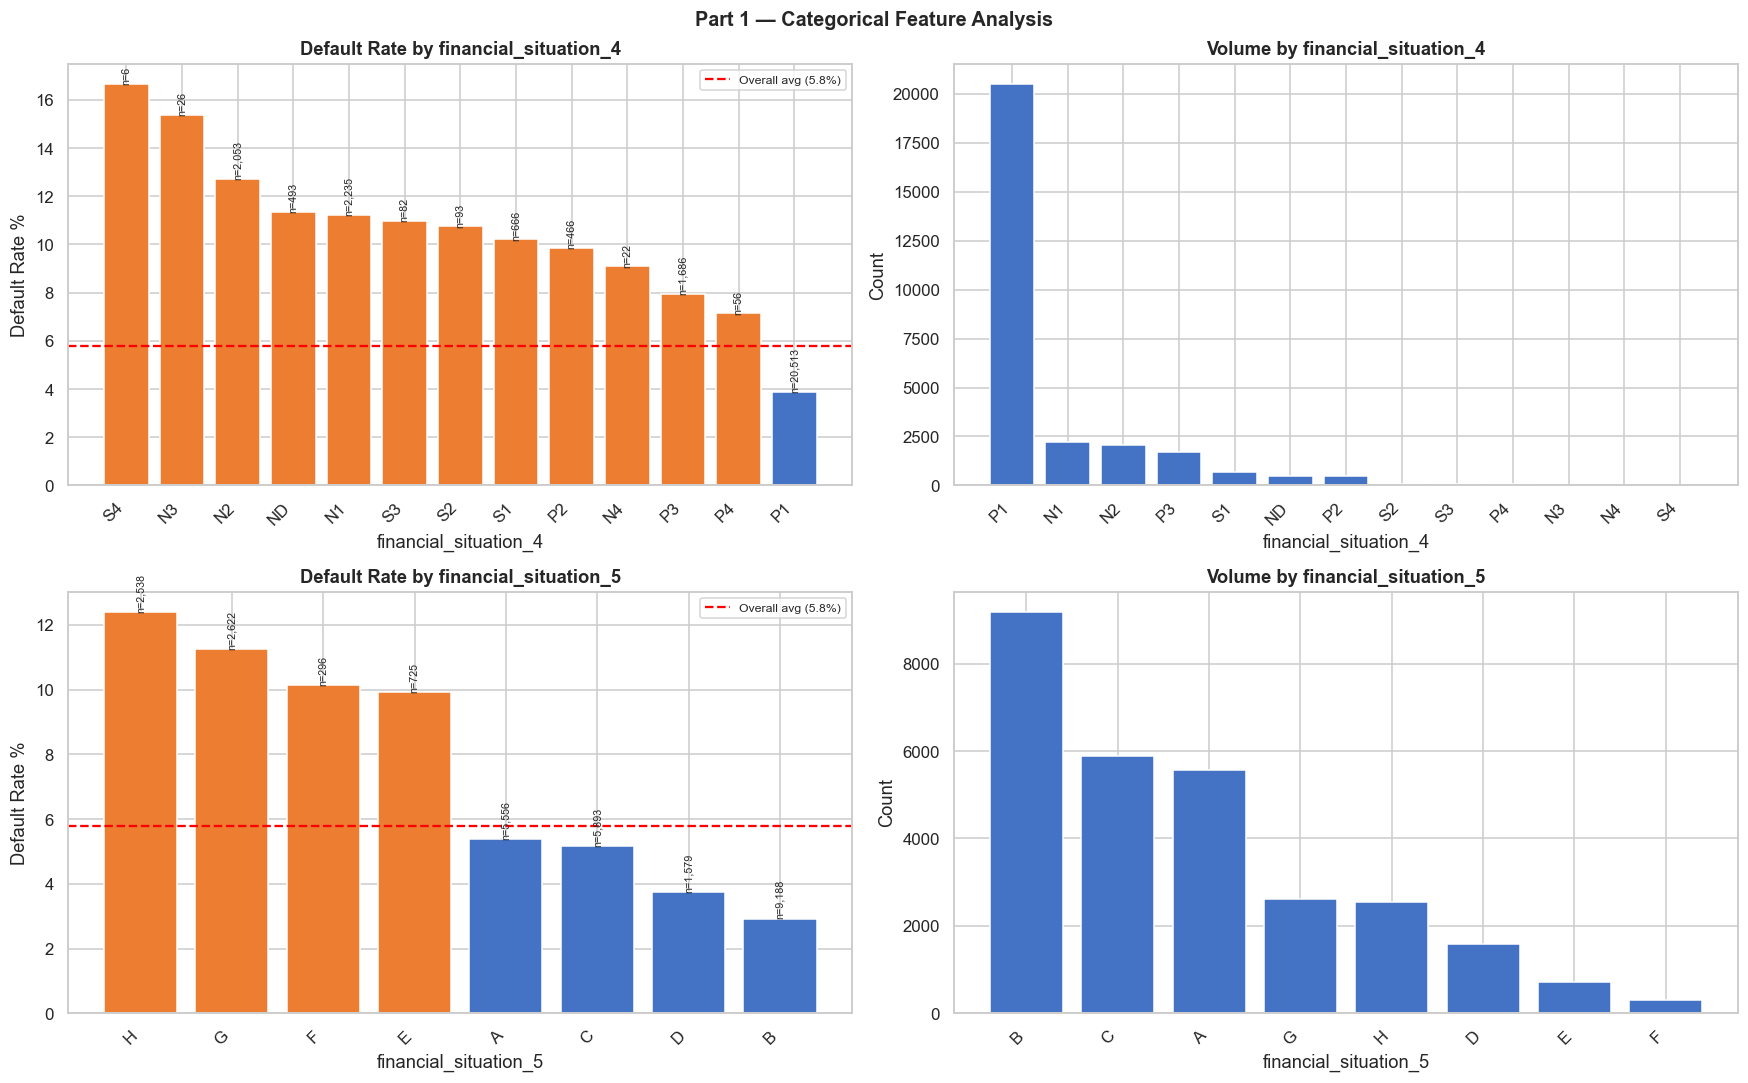

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Part 1 — Categorical Feature Analysis", fontsize=13, fontweight="bold")

for i, col in enumerate(cat_cols):
    # Default rate by category
    ax = axes[i][0]
    dr = (train.groupby(col)["label"]
               .agg(["mean","count"])
               .reset_index()
               .assign(default_rate_pct=lambda x: x["mean"]*100)
               .sort_values("default_rate_pct", ascending=False))
    avg_dr = train["label"].mean() * 100
    palette = [ORANGE if v > avg_dr else BLUE for v in dr["default_rate_pct"].values]
    bars = ax.bar(dr[col].astype(str), dr["default_rate_pct"],
                  color=palette, edgecolor="white")
    ax.axhline(avg_dr, color="red", linestyle="--", lw=1.5,
               label=f"Overall avg ({avg_dr:.1f}%)")
    ax.set_title(f"Default Rate by {col}", fontweight="bold")
    ax.set_ylabel("Default Rate %"); ax.set_xlabel(col)
    ax.legend(fontsize=8)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    for bar, (_, row) in zip(bars, dr.iterrows()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                f"n={int(row['count']):,}", ha="center", fontsize=7, rotation=90)

    # Volume per category
    ax = axes[i][1]
    vol = train[col].value_counts().sort_values(ascending=False)
    ax.bar(vol.index.astype(str), vol.values, color=BLUE, edgecolor="white")
    ax.set_title(f"Volume by {col}", fontweight="bold")
    ax.set_ylabel("Count"); ax.set_xlabel(col)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

---
## Summary & Key Takeaways

| Finding | Detail |
|---|---|
| **Data size** | 28,397 train rows, 4,000 test rows, 100 features |
| **Feature types** | 98 numeric (float64), 2 categorical (`financial_situation_4/5`) |
| **Feature families** | 9 families — repayment_history (31), balance (24), utilization (18), recency (12)... |
| **Merge** | 2 orphan X_train rows (no label) — dropped safely; test merges perfectly |
| **Leakage** | ✅ Zero train/test overlap |
| **Duplicates** | ✅ Zero duplicate account_ids; 1 fully-duplicate row in X_train (harmless) |
| **Class imbalance** | 5.79% default rate — **16.3:1 ratio** — use AUC + Avg Precision, not accuracy |
| **Missing values** | 0 features are fully complete; 30 features >50% missing — NaN is informative |
| **Bureau score** | Defaulters avg score = 568 vs 731 for non-defaulters — clear signal, good baseline |
| **Outliers** | Intentional noise added; tree models are robust — no clipping planned |

### Next Step → **Part 2: Exploratory Data Analysis**
- Deep-dive into each feature family
- Correlation & discriminative power analysis
- Distribution plots by label
- Feature interaction exploration